# Genes mirror geography — PCA on 2,504 human genomes

**Instructor-led practical, chapter 10.** In 2008, Novembre et al. ran plain PCA on the DNA of
~1,400 Europeans and the scatter of PC1 vs PC2 came out looking like **the map of Europe** (the published axes are rotated $-16^\circ$ to line up with geography - the structure is PCA's, the orientation is the authors')
([*Genes mirror geography within Europe*, Nature 2008](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2735096/)).
Nobody told the algorithm anything about geography.

Today we reproduce that idea on fully open data: **1000 Genomes phase 3**, 2,504 people from 26
populations, using only **chromosome 22** and only the tools from the lecture. Everything loads
from `data/genomes_1000g_chr22.npz` — numpy, no bioinformatics stack.
([population codes](https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/README_populations.md))

In [1]:
import os, sys
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(v, "4")          # keep the laptop usable

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

SEED = 509
rng = np.random.default_rng(SEED)
sys.path.insert(0, str(Path.cwd()))        # for the given py_src helpers
from py_src.genes_geography_maps import (coastlines, draw_map, SITES,
                                         SUPER_COLORS, SUPER_NAMES, EUR_NAMES)

d = np.load("data/genomes_1000g_chr22.npz", allow_pickle=True)
X, pop, sup = d["genotypes"], d["pop"], d["super_pop"]
print(f"genotype matrix: {X.shape[0]} people x {X.shape[1]} SNPs, dtype {X.dtype}")
for s in sorted(set(sup)):
    print(f"  {s} - {SUPER_NAMES[s]:<12} {(sup == s).sum():>4} people")
print("source:", str(d["source"]))

genotype matrix: 2504 people x 16202 SNPs, dtype int8
  AFR - African       661 people
  AMR - American      347 people
  EAS - East Asian    504 people
  EUR - European      503 people
  SAS - South Asian   489 people
source: http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz


## Act 0 — what is this matrix?

A **row is a person**. A **column is a SNP** — one position in the genome where humans are known
to differ by a single letter. The value counts how many copies of the *alternate* letter that
person carries: **0, 1, or 2** (one from each parent). We kept only *common* variants (frequency 5-95%): a rare variant is individually too noisy to help a PCA of this size, and the frequency scaling in the next act would blow it up.

That makes this the widest dataset of the course so far: 16,202 features for 2,504 samples —
the curse-of-dimensionality frame, now with people as the rows.

**Predict first:** if PCA ranks directions by variance — what will PC1 of humanity *be*?

In [2]:
print(X[:5, :8], "\n")
for v, c in zip(*np.unique(X, return_counts=True)):
    print(f"value {v}: {c / X.size:.1%} of the matrix")

[[1 1 0 0 0 0 1 0]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 0 1 0 0]
 [2 0 1 2 1 2 1 2]
 [2 0 1 2 1 2 1 1]] 



value 0: 54.8% of the matrix
value 1: 28.1% of the matrix
value 2: 17.0% of the matrix


## Act 1 — PCA of raw genotype counts

One scaling decision first, exactly the lecture's scaling-trap frame: all columns are already in
the *same units* (0/1/2), so centering is mandatory, standardizing is a **choice**. Population
genetics has its own convention — divide each SNP by $\sqrt{p(1-p)}$ - the standard deviation of a single allele draw (Patterson et al. 2006). Let's measure whether it matters here.

In [3]:
def pca_scores(X, n=10, patterson=True):
    """Center each SNP; optionally scale by sqrt(p(1-p)) (Patterson et al. 2006)."""
    X = X.astype(np.float32)
    p = X.mean(axis=0) / 2.0                  # allele frequency per SNP
    Xc = X - 2.0 * p
    if patterson:
        Xc /= np.sqrt(p * (1.0 - p))
    pca = PCA(n_components=n, random_state=SEED)
    return pca.fit_transform(Xc), pca.explained_variance_ratio_

for patterson in (False, True):
    Z, evr = pca_scores(X, patterson=patterson)
    sil = silhouette_score(Z[:, :2], sup)
    print(f"patterson={patterson!s:<5}  EVR(PC1, PC2) = {evr[0]:.3f}, {evr[1]:.3f}   "
          f"silhouette of 5 super-pops on PC1-2 = {sil:.3f}")

Z, evr = pca_scores(X)   # Patterson scaling from here on

patterson=False  EVR(PC1, PC2) = 0.101, 0.045   silhouette of 5 super-pops on PC1-2 = 0.574


patterson=True   EVR(PC1, PC2) = 0.102, 0.041   silhouette of 5 super-pops on PC1-2 = 0.588


Barely any difference (0.574 vs 0.588) — when the structure is this strong, the scaling knob
stops mattering. Now the answer to the predict-first question, with the sampling map alongside:

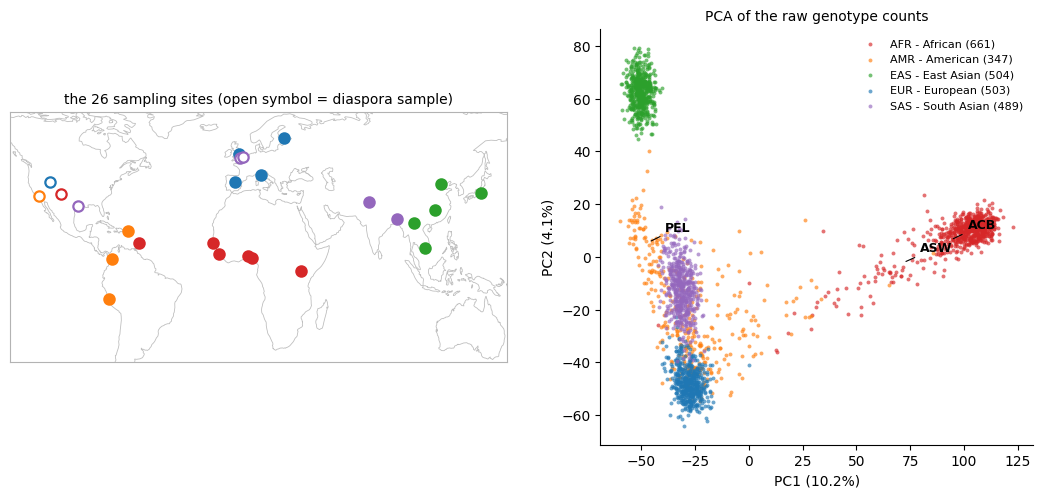

In [4]:
lines = coastlines()
fig, (axm, axp) = plt.subplots(1, 2, figsize=(13.2, 5.4), gridspec_kw={"width_ratios": [1.15, 1]})
draw_map(axm, lines, (-135, 155, -40, 72))
for c26, (lon, lat, diaspora) in SITES.items():
    col = SUPER_COLORS[sup[pop == c26][0]]
    axm.scatter(lon, lat, s=55, color="white" if diaspora else col, edgecolors=col,
                linewidths=1.6, zorder=3)
axm.set_title("the 26 sampling sites (open symbol = diaspora sample)", fontsize=10)

for s in sorted(SUPER_NAMES):
    m = sup == s
    axp.scatter(Z[m, 0], Z[m, 1], s=8, alpha=0.65, color=SUPER_COLORS[s], linewidths=0,
                label=f"{s} - {SUPER_NAMES[s]} ({m.sum()})")
for c26 in ("PEL", "ASW", "ACB"):        # name the admixture, don't recolor it
    med = np.median(Z[pop == c26, :2], axis=0)
    axp.annotate(c26, med, textcoords="offset points", xytext=(12, 8), fontsize=9,
                 fontweight="bold", arrowprops=dict(arrowstyle="-", lw=0.8))
axp.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)"); axp.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
axp.set_title("PCA of the raw genotype counts", fontsize=10)
axp.legend(frameon=False, fontsize=8, loc="upper right")
axp.spines[["top", "right"]].set_visible(False)
plt.show()

**PC1 of humanity is ancestry** — the two largest directions of variance in these 16,202
columns separate the five continental groups. And read the **smears**: the AMR populations (orange - Lima, Mexican-ancestry LA, Puerto Rico, Medellin) and the African-diaspora samples (ASW, ACB - colored AFR **red**, trailing toward the other clusters) are *admixed*, and their genomes really are continuous mixtures - the smears are not noise, they are history. Hold that thought for Act 3.

Also note what PCA did **not** need: no labels, no geography, no model of migration. Variance
alone. (And note the diaspora samples on the map — sampled in Utah, Houston, the UK — sit with
their *ancestry* in the PCA, not with their address.)

One preview of Act 2's lesson: the five *tidy clusters* are partly a sampling artifact themselves - 1000G sampled 26 distinct populations far apart, with nobody from the Middle East, North Africa, Central Asia or Oceania. Sample the in-betweens and the gaps would fill with gradients. (An Armenian sample, for instance, would land squarely in one of those gaps.)

## Act 2 — Europe only. Predict first: these 503 people are all one color above. Does PCA see *anything* inside?

In [5]:
eur = sup == "EUR"
try:
    Ze, evr_e = pca_scores(X[eur])
except ValueError as e:
    print("PCA refused the matrix:", str(e).splitlines()[0])

PCA refused the matrix: Input X contains NaN.


C:\Users\hayk_\AppData\Local\Temp\ipykernel_8916\1507455135.py:7: RuntimeWarning: invalid value encountered in divide
  Xc /= np.sqrt(p * (1.0 - p))


In [6]:
# Diagnose it ourselves. p(1-p) hit zero somewhere:
p_eur = X[eur].astype(np.float32).mean(axis=0) / 2
mono = (p_eur == 0) | (p_eur == 1)
print(f"{mono.sum()} of {len(p_eur)} SNPs are monomorphic WITHIN Europe -")
print("common somewhere in the world, but every European carries the same genotype.")
print("Zero variance in this subset -> sqrt(p(1-p)) = 0 -> division by zero -> NaN.")

323 of 16202 SNPs are monomorphic WITHIN Europe -
common somewhere in the world, but every European carries the same genotype.
Zero variance in this subset -> sqrt(p(1-p)) = 0 -> division by zero -> NaN.


(numpy's red `RuntimeWarning` above was the first clue: *invalid value encountered in divide*.)

This is a *general* PCA lesson, not a genetics quirk: **subset your data and features can go
constant** — and any per-feature scaling then divides by zero. The fix is explicit and loud:

dropping 323 SNPs monomorphic in this subset

median PC1/PC2  CEU: [-1.6 -0.2]
median PC1/PC2  FIN: [-3.  27.6]
median PC1/PC2  GBR: [-7.1  1. ]
median PC1/PC2  IBS: [ -6.8 -12.1]
median PC1/PC2  TSI: [ -6.2 -11.7]


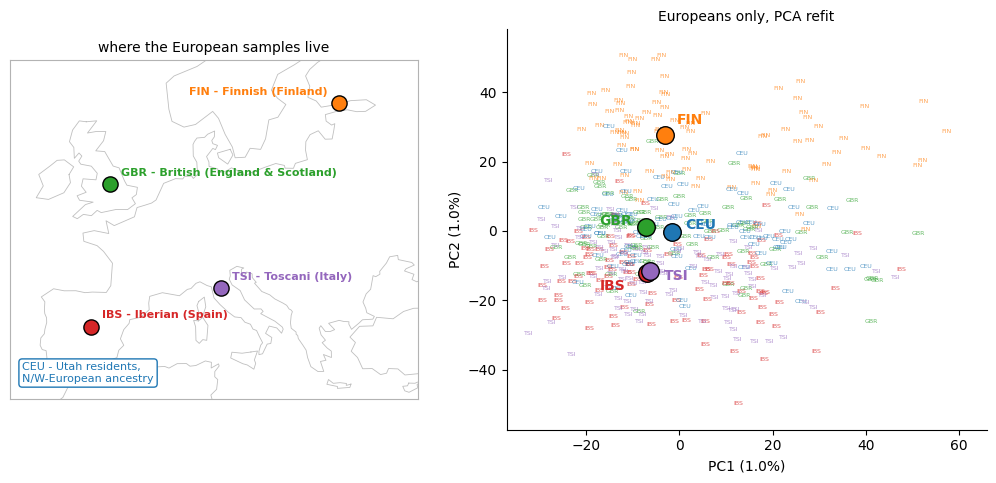

In [7]:
def pca_scores_safe(X, n=10):
    """Patterson-scaled PCA that DROPS features with zero variance in this subset - loudly."""
    X = X.astype(np.float32)
    p = X.mean(axis=0) / 2.0
    keep = (p > 0) & (p < 1)
    if not keep.all():
        print(f"dropping {(~keep).sum()} SNPs monomorphic in this subset")
        X, p = X[:, keep], p[keep]
    Xc = (X - 2.0 * p) / np.sqrt(p * (1.0 - p))
    pca = PCA(n_components=n, random_state=SEED)
    return pca.fit_transform(Xc), pca.explained_variance_ratio_

Ze, evr_e = pca_scores_safe(X[eur])
pe = pop[eur]

cmap = dict(zip(sorted(set(pe)), plt.cm.tab10.colors))
fig, (axm, axp) = plt.subplots(1, 2, figsize=(12.6, 5.2), gridspec_kw={"width_ratios": [0.85, 1]})
draw_map(axm, lines, (-13, 34, 34, 64))
for c5 in sorted(set(pe)):
    lon, lat, diaspora = SITES[c5]
    if diaspora:                                   # CEU was sampled in Utah
        axm.annotate("CEU - Utah residents,\nN/W-European ancestry", (0.03, 0.05),
                     xycoords="axes fraction", fontsize=8, color=cmap[c5],
                     bbox=dict(boxstyle="round", fc="white", ec=cmap[c5]))
        continue
    axm.scatter(lon, lat, s=120, color=cmap[c5], edgecolors="black", zorder=3)
    axm.annotate(f"{c5} - {EUR_NAMES[c5]}", (lon, lat), textcoords="offset points",
                 xytext=(-8, 6) if c5 == "FIN" else (8, 6),
                 ha="right" if c5 == "FIN" else "left",
                 fontsize=8, color=cmap[c5], fontweight="bold")
axm.set_title("where the European samples live", fontsize=10)

for i in range(len(Ze)):
    axp.text(Ze[i, 0], Ze[i, 1], pe[i], color=cmap[pe[i]], fontsize=4.5,
             ha="center", va="center", alpha=0.7)
offs = {"CEU": (10, 2), "FIN": (8, 8), "GBR": (-34, 2), "IBS": (-34, -12), "TSI": (10, -6)}
for c5 in sorted(set(pe)):
    med = np.median(Ze[pe == c5, :2], axis=0)
    axp.scatter(*med, s=160, color=cmap[c5], edgecolors="black", zorder=5)
    axp.annotate(c5, med, textcoords="offset points", xytext=offs[c5], fontsize=10,
                 fontweight="bold", color=cmap[c5])
    print(f"median PC1/PC2  {c5}: {np.round(med, 1)}")
axp.set_xlim(Ze[:, 0].min() * 1.15, Ze[:, 0].max() * 1.15)
axp.set_ylim(Ze[:, 1].min() * 1.15, Ze[:, 1].max() * 1.15)
axp.set_xlabel(f"PC1 ({evr_e[0]*100:.1f}%)"); axp.set_ylabel(f"PC2 ({evr_e[1]*100:.1f}%)")
axp.set_title("Europeans only, PCA refit", fontsize=10)
axp.spines[["top", "right"]].set_visible(False)
plt.show()

**Finland separates unmistakably; the mainland stays a cloud.** The north–south axis is real
(look at the median dots), but Spain vs Italy does not resolve — and no amount of chr22 helps:
we measured the same plot with **all 97k** passing chr22 SNPs: the Iberian-Tuscan separation (median-to-median distance over the mean within-population spread) grew about 2.5x, from 0.06 to 0.15 - roughly the $\sqrt{6}$ that averaging 6x more features predicts - and is still invisible.

So how did Novembre get the *map*? Not a better algorithm — **better sampling**: ~1,400 people at country level across ~36 countries, genotyped on a 500k chip (~197k SNPs after quality control) - POPRES, which is controlled-access.
[Their Figure 1](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2735096/figure/F1/) is the closer
for this act. *The resolution of a PCA picture is set by the sampling design, not by PCA.*

## Act 3 — the pretty maps: t-SNE and UMAP

The lecture's recipe, verbatim: PCA to ~25 components first (denoise + speed), then the
nonlinear methods on the PC scores. *(First `import umap` JIT-compiles for ~2 minutes; the cell
caches its result so re-runs are instant.)*

In [8]:
Zp, _ = pca_scores_safe(X, n=25)
cache = Path("out/gg_embeddings.npz")
if cache.exists():
    e = np.load(cache)
    Zt, Zu = e["tsne"], e["umap"]
    print("loaded cached embeddings (delete out/gg_embeddings.npz to recompute)")
else:
    print("t-SNE ... (~1 min)")
    Zt = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(Zp)
    print("UMAP ... ")
    import umap
    Zu = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED).fit_transform(Zp)
    Path("out").mkdir(exist_ok=True)
    np.savez_compressed(cache, tsne=Zt, umap=Zu)

loaded cached embeddings (delete out/gg_embeddings.npz to recompute)


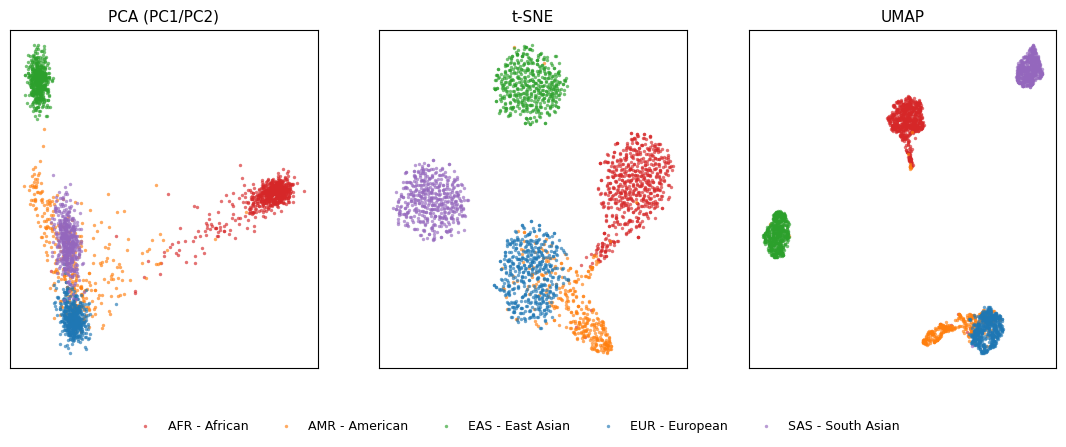

silhouette         5 super-pops  26 populations


PCA (PC1/PC2)             0.588          -0.127


t-SNE                     0.591          -0.058


UMAP                      0.712          -0.075


In [9]:
embeddings = [("PCA (PC1/PC2)", Zp[:, :2]), ("t-SNE", Zt), ("UMAP", Zu)]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, (name, Zx) in zip(axes, embeddings):
    for s in sorted(SUPER_NAMES):
        m = sup == s
        ax.scatter(Zx[m, 0], Zx[m, 1], s=6, alpha=0.65, color=SUPER_COLORS[s],
                   linewidths=0, label=f"{s} - {SUPER_NAMES[s]}")
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
fig.legend(*axes[0].get_legend_handles_labels(), ncol=5, frameon=False,
           loc="lower center", bbox_to_anchor=(0.5, -0.06), fontsize=9)
plt.show()

print(f"silhouette        {'5 super-pops':>13} {'26 populations':>15}")
for name, Zx in embeddings:
    print(f"{name:<17} {silhouette_score(Zx, sup):>13.3f} {silhouette_score(Zx, pop):>15.3f}")

Three readings, in the order the numbers force them:

1. **UMAP "wins"** — the crispest continents (silhouette 0.71 vs PCA's 0.59).
2. **But the prettiest map is not the truest.** PCA's orange smear was *real admixture* — a
   continuum. UMAP compressed that continuum into a tongue stuck to the European island; the
   in-between-ness is mostly gone. Crispness manufactured discreteness. (The same complaint is
   published about single-cell biology: Chari & Pachter, *The specious art of single-cell
   genomics*, PLOS Comp Bio 2023.)
3. **The 26 fine populations separate in NO 2-D map** — every silhouette in that column is
   negative. Fine structure needs genome-wide data; chr22 does not carry it, and an honest
   negative number beats a hopeful picture.

And one lecture-36 callback you can now check by eye: the *distances between* UMAP's islands
mean nothing — you cannot ask "is South Asia genetically closer to East Asia or to Europe?"
from the UMAP panel. From PCA, you can.

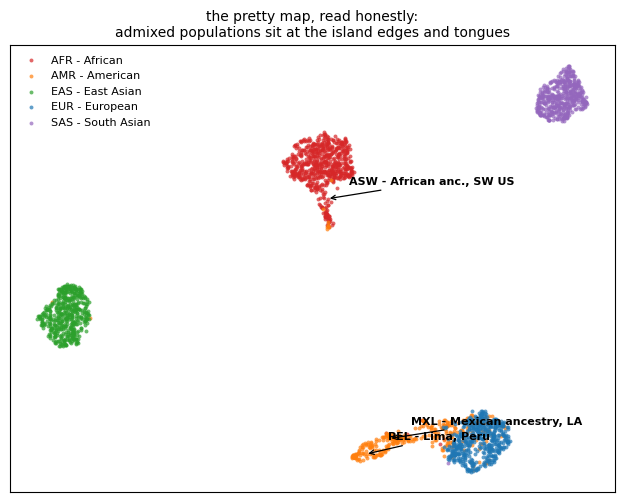

In [10]:
fig, ax = plt.subplots(figsize=(7.8, 5.8))
for s in sorted(SUPER_NAMES):
    m = sup == s
    ax.scatter(Zu[m, 0], Zu[m, 1], s=8, alpha=0.7, color=SUPER_COLORS[s], linewidths=0,
               label=f"{s} - {SUPER_NAMES[s]}")
for c26, label in [("PEL", "PEL - Lima, Peru"), ("MXL", "MXL - Mexican ancestry, LA"),
                   ("ASW", "ASW - African anc., SW US")]:
    med = np.median(Zu[pop == c26], axis=0)
    ax.annotate(label, med, textcoords="offset points", xytext=(16, 10), fontsize=8,
                fontweight="bold", arrowprops=dict(arrowstyle="->", lw=0.9))
ax.set_xticks([]); ax.set_yticks([])
ax.legend(frameon=False, fontsize=8)
ax.set_title("the pretty map, read honestly:\nadmixed populations sit at the island edges and tongues",
             fontsize=10)
plt.show()

## Act 4 — new points on fixed axes

The decision table's "New points?" column, live: PCA is a *map*, not just a picture. Hold 100
people out, fit the axes without them, then `transform` them:

**Predict first:** we then classify the 100 by nearest super-population centroid, once with 2 PCs and once with 10. Which wins - and *where* do the errors move?

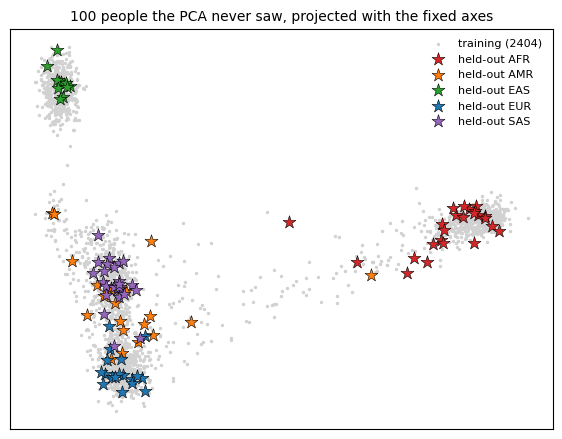

 2 PCs (14% of the variance): 80% correct   (AFR 24/25  AMR 10/20  EAS 12/12  EUR 16/18  SAS 18/25)


10 PCs (19% of the variance): 93% correct   (AFR 24/25  AMR 14/20  EAS 12/12  EUR 18/18  SAS 25/25)


In [11]:
idx = np.random.default_rng(SEED).permutation(len(X))   # fresh generator: re-running
# this cell must give the SAME split (a shared rng would silently reshuffle)
hold, train = idx[:100], idx[100:]
Xtr = X[train].astype(np.float32)
p_tr = Xtr.mean(axis=0) / 2
keep = (p_tr > 0) & (p_tr < 1)

def scale(A):                                      # the TRAINING p, both times
    return (A[:, keep] - 2 * p_tr[keep]) / np.sqrt(p_tr[keep] * (1 - p_tr[keep]))

pca2 = PCA(n_components=2, random_state=SEED).fit(scale(Xtr))
Ztr = pca2.transform(scale(Xtr))
Zho = pca2.transform(scale(X[hold].astype(np.float32)))

fig, ax = plt.subplots(figsize=(7.0, 5.2))
ax.scatter(Ztr[:, 0], Ztr[:, 1], s=6, color="0.82", linewidths=0, label=f"training ({len(train)})")
for s in sorted(SUPER_NAMES):
    m = sup[hold] == s
    ax.scatter(Zho[m, 0], Zho[m, 1], marker="*", s=95, color=SUPER_COLORS[s],
               edgecolors="black", linewidths=0.4, label=f"held-out {s}")
ax.legend(frameon=False, fontsize=8); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("100 people the PCA never saw, projected with the fixed axes", fontsize=10)
plt.show()

# Nearest super-population centroid, with 2 PCs vs 10 PCs.
for n in (2, 10):
    pca = PCA(n_components=n, random_state=SEED).fit(scale(Xtr))
    Zt_, Zh_ = pca.transform(scale(Xtr)), pca.transform(scale(X[hold].astype(np.float32)))
    cent = {s: np.median(Zt_[sup[train] == s], axis=0) for s in sorted(set(sup))}
    D = np.linalg.norm(Zh_[:, None, :] - np.array(list(cent.values()))[None], axis=2)
    pred = np.array(list(cent))[D.argmin(axis=1)]
    per = "  ".join(f"{s} {((pred == sup[hold]) & (sup[hold] == s)).sum()}/{(sup[hold] == s).sum()}"
                    for s in sorted(set(sup[hold])))
    print(f"{n:>2} PCs ({pca.explained_variance_ratio_.sum():.0%} of the variance): "
          f"{(pred == sup[hold]).mean():.0%} correct   ({per})")

Two lessons in one number:

1. **80% with 2 components, 93% with 10.** The 2-D map is for *eyes*; a model gets more
   components - the deck's "do not feed the 2-D picture to a model" caveat, measured. With
   10 PCs the South Asian and European misses vanish entirely.
2. **What remains at 93% is almost all AMR** - the admixed samples, whose nearest centroid is
   legitimately ambiguous. The errors that survive are the history, not the method.

Either way, PCA learned a *reusable coordinate system* for ancestry from raw counts, with no
labels. (t-SNE could not do this at all - no out-of-sample map - and UMAP only approximately.)

## Wrap-up

| you can trust | you cannot trust |
|---|---|
| PC1/PC2 = ancestry structure (variance found it, unsupervised) | 2-D distances *between* UMAP/t-SNE islands |
| the admixture smears in PCA - they are real history | crisp island boundaries - they can manufacture discreteness |
| projecting *new* people onto fixed PCs | 26-population "clusters" - silhouettes are negative, don't narrate them |
| the north-south signal in Europe (medians) | Spain-vs-Italy stories at this resolution |

One careful closing note for the room: these principal components are **continuous gradients
shaped by migration and drift**, not categories - the picture argues *against* discrete
"races", not for them; the smears and tongues are the point.

**References.** Novembre et al., [*Genes mirror geography within Europe*](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2735096/), Nature 2008 (1,387 people, ~197k QC'd SNPs, POPRES) ·
[1000 Genomes phase 3](https://www.internationalgenome.org/) (open data; [population codes](https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/README_populations.md)) ·
Patterson, Price & Reich, *Population structure and eigenanalysis*, PLoS Genetics 2006 ·
Chari & Pachter, [*The specious art of single-cell genomics*](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011288), PLOS Comp Bio 2023.
Data prep: `py_src/fetch_1000g_genotypes.py`; validation record: `py_src/non_essential/validate_genes_geography.py`, DECISIONS.md #32.